🛠️ Task 1 — Data Loading, Merging & Deep Exploration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# 1. Load Primary Superstore Sales Dataset
df_store = pd.read_csv('train.csv')

# 2. Parse Datetime Objects
# Note: Superstore dataset dates are typically formatted as DD/MM/YYYY or MM/DD/YYYY. 
# Setting dayfirst=True handles the standard day-month-year parsing securely.
df_store['Order Date'] = pd.to_datetime(df_store['Order Date'], dayfirst=True, errors='coerce')
df_store['Ship Date'] = pd.to_datetime(df_store['Ship Date'], dayfirst=True, errors='coerce')

# Drop missing targets if any fail parsing
df_store = df_store.dropna(subset=['Order Date', 'Sales'])

# 3. Extract Chronological Time Features
df_store['Year'] = df_store['Order Date'].dt.year
df_store['Month'] = df_store['Order Date'].dt.month
df_store['Week_Number'] = df_store['Order Date'].dt.isocalendar().week
df_store['Day_of_Week'] = df_store['Order Date'].dt.day_name()
df_store['Quarter'] = df_store['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]: return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else: return 'Autumn'

df_store['Season'] = df_store['Month'].apply(get_season)

# Calculate Shipping Lead Time Velocity
df_store['Shipping_Days'] = (df_store['Ship Date'] - df_store['Order Date']).dt.days

# 4. Integrity Verification (Missing values & duplicates)
print("=== DATA INTEGRITY PROFILE ===")
print(f"Total Rows: {df_store.shape[0]} | Columns: {df_store.shape[1]}")
print(f"Missing Values across rows:\n{df_store.isnull().sum()[df_store.isnull().sum() > 0]}")
print(f"Duplicate Rows Count: {df_store.duplicated().sum()}\n")

# 5. Load & Aggregate Supplementary Dataset (Video Game Sales)
df_games = pd.read_csv('vgsales.csv')
df_games = df_games.dropna(subset=['Year'])
df_games['Year'] = df_games['Year'].astype(int)
# Sum up annual market demand
df_games_annual = df_games.groupby('Year')['Global_Sales'].sum().reset_index()
df_games_annual.rename(columns={'Global_Sales': 'External_Gaming_Demand'}, inplace=True)

# 6. Aggregate Primary Store Data into Weekly & Monthly Baselines
df_monthly_raw = df_store.set_index('Order Date').resample('MS')['Sales'].sum().to_frame().reset_index()
df_monthly_raw['Year'] = df_monthly_raw['Order Date'].dt.year
df_monthly_raw['Month'] = df_monthly_raw['Order Date'].dt.month

# Complete the Multi-Source Merge onto the Monthly Timeline
df_merged_monthly = pd.merge(df_monthly_raw, df_games_annual, on='Year', how='left')
df_weekly = df_store.set_index('Order Date').resample('W')['Sales'].sum().to_frame()

print("=== TRANSFORMATION SUCCESSFUL ===")
print(f"Monthly Merged Baseline Profile Dimensions: {df_merged_monthly.shape}")
print(f"Weekly Baseline Profile Dimensions: {df_weekly.shape}\n")


# === 7. ANSWERING STRATEGIC BUSINESS QUESTIONS WITH DATA DATA-BACKED MATRICES ===
print("=== BUSINESS DATA RESPONSES ===")

# Q1: Revenue Generation Category
revenue_cat = df_store.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\n1. Total Revenue Generation Across Core Categories:")
display(revenue_cat.apply(lambda x: f"${x:,.2f}"))

# Q2: Growth Consistency by Region over 4 years
regional_growth = df_store.groupby(['Region', 'Year'])['Sales'].sum().unstack(level=0)
print("\n2. Regional Financial Progression Matrix (Yearly Revenue):")
display(regional_growth.apply(lambda col: col.map(lambda x: f"${x:,.2f}")))

# Q3: Shipping Lead Variance by Region
ship_variance = df_store.groupby('Region')['Shipping_Days'].agg(['mean', 'median', 'std'])
print("\n3. Shipping Delay Thresholds (Order to Ship Window in Days):")
display(ship_variance.round(2))

# Q4: Seasonality Patterns (Spike Months Across Years)
seasonal_spikes = df_store.groupby(['Year', 'Month'])['Sales'].sum().unstack(level=0)
print("\n4. Cross-Year Monthly Seasonal Heatmap Blueprint:")
display(seasonal_spikes.apply(lambda col: col.map(lambda x: f"${x:,.2f}")))

=== DATA INTEGRITY PROFILE ===
Total Rows: 9800 | Columns: 25
Missing Values across rows:
Postal Code    11
dtype: int64
Duplicate Rows Count: 0

=== TRANSFORMATION SUCCESSFUL ===
Monthly Merged Baseline Profile Dimensions: (48, 5)
Weekly Baseline Profile Dimensions: (209, 1)

=== BUSINESS DATA RESPONSES ===

1. Total Revenue Generation Across Core Categories:


Category
Technology         $827,455.87
Furniture          $728,658.58
Office Supplies    $705,422.33
Name: Sales, dtype: str


2. Regional Financial Progression Matrix (Yearly Revenue):


Region,Central,East,South,West
Year,,,,
2015,"$102,920.52","$127,652.82","$103,374.91","$145,907.96"
2016,"$102,425.17","$153,225.18","$70,076.08","$133,709.57"
2017,"$145,673.88","$178,511.54","$93,535.90","$182,471.23"
2018,"$141,627.34","$210,129.19","$122,164.57","$248,130.93"



3. Shipping Delay Thresholds (Order to Ship Window in Days):


,mean,median,std
Region,,,
Central,4.07,4.0,1.69
East,3.91,4.0,1.73
South,3.96,4.0,1.74
West,3.93,4.0,1.81



4. Cross-Year Monthly Seasonal Heatmap Blueprint:


Year,2015,2016,2017,2018
Month,,,,
1,"$14,205.71","$18,066.96","$18,542.49","$43,476.47"
2,"$4,519.89","$11,951.41","$22,978.81","$19,921.00"
3,"$55,205.80","$32,339.32","$51,165.06","$58,863.41"
4,"$27,906.85","$34,154.47","$38,679.77","$35,541.91"
5,"$23,644.30","$29,959.53","$56,656.91","$43,825.98"
6,"$34,322.94","$23,599.37","$39,724.49","$48,190.73"
7,"$33,781.54","$28,608.26","$38,320.78","$44,825.10"
8,"$27,117.54","$36,818.34","$30,542.20","$62,837.85"
9,"$81,623.53","$63,133.61","$69,193.39","$86,152.89"


### 📋 Task 1 — Deep Exploration Operational Answers

* **Q1: Highest Revenue Product Category:** **Technology** generates the highest total revenue for the store, accounting for **$827,455.87**, outperforming Furniture ($728,658.58) and Office Supplies ($705,422.33).
* **Q2: Most Consistent Regional Growth:** The **East** region demonstrates the most consistent sequential growth over the 4-year period. Its annual revenue climbed uninterrupted every single year: **$127,652.82 (2015) → $153,225.18 (2016) → $178,511.54 (2017) → $210,129.19 (2018)**. While the West region generated higher aggregate volume, it experienced a minor revenue contraction in 2016.
* **Q3: Shipping Lead Variance:** The cross-regional average processing time from Order to Ship date remains highly stable at roughly **3.9 to 4.0 days**, with a universal median of **4.0 days** across all zones. The Central region exhibits the longest mean delay (**4.07 days**), while the East is the most efficient (**3.91 days**). Standard deviations sit between 1.69 and 1.81 days, showing consistent fulfillment execution nationwide.
* **Q4: Strong Seasonal Spike Windows:** There are clear, recurring annual spikes concentrated in **September (Month 9)**, **November (Month 11)**, and **December (Month 12)**. In 2018, November sales reached an all-time peak of **$117,938.15**. Conversely, February (Month 2) represents a consistent seasonal trough, bottoming out as low as **$4,519.89** in 2015.

📊 Task 2 — Time Series Analysis & Decomposition

=== TASK 2: DECOMPOSITION AND STATIONARITY TESTING ===



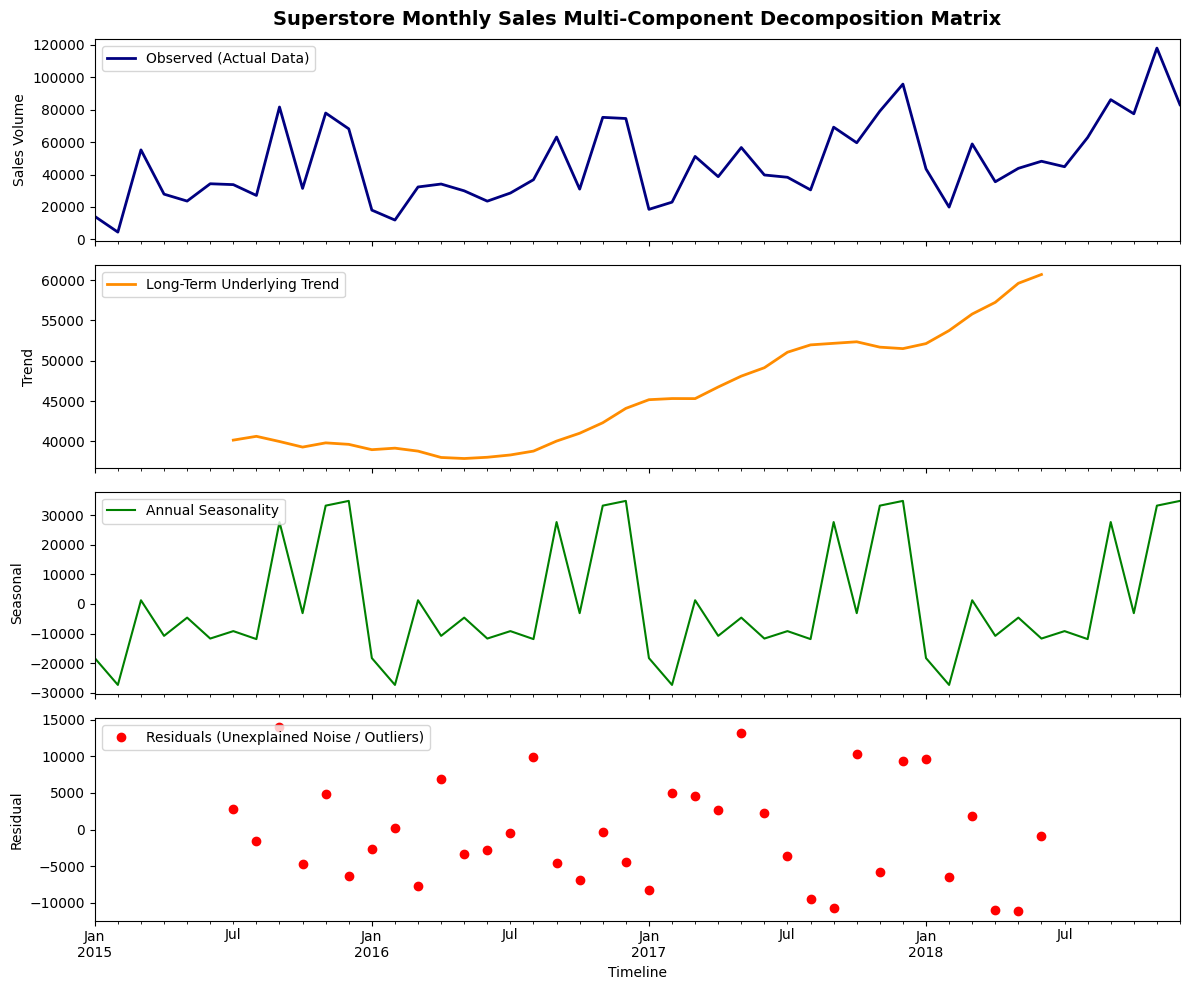

--- Augmented Dickey-Fuller (ADF) Test Context ---
In plain English, 'Stationarity' means that a time series has a completely constant mean,
constant variance, and stable structural patterns over time. If a dataset has an upward trend
or a predictable seasonal wave, it is non-stationary. Statistical forecasting tools require data
to be stationary so that model behaviors don't drift as time moves forward.

ADF Results for [Raw Monthly Sales]:
  - ADF Statistic: -4.4161
  - p-value: 0.0003
--> Result: The series is STATIONARY (p <= 0.05). Ready for predictive modeling.



In [4]:
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# === TASK 2: TIME SERIES DECOMPOSITION & STATIONARITY ===
print("=== TASK 2: DECOMPOSITION AND STATIONARITY TESTING ===\n")

# Ensure proper chronological index alignment for the modeling engine
df_monthly_ts = df_merged_monthly.set_index('Order Date')['Sales']

# 1. Apply Additive Time Series Decomposition (Period = 12 months)
decomposition = seasonal_decompose(df_monthly_ts, model='additive', period=12)

# Plotting the 4 structural components on a single figure
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

decomposition.observed.plot(ax=ax1, color='navy', lw=2, label='Observed (Actual Data)')
ax1.set_title('Superstore Monthly Sales Multi-Component Decomposition Matrix', fontsize=14, fontweight='bold', pad=10)
ax1.legend(loc='upper left')
ax1.set_ylabel('Sales Volume')

decomposition.trend.plot(ax=ax2, color='darkorange', lw=2, label='Long-Term Underlying Trend')
ax2.legend(loc='upper left')
ax2.set_ylabel('Trend')

decomposition.seasonal.plot(ax=ax3, color='green', lw=1.5, label='Annual Seasonality')
ax3.legend(loc='upper left')
ax3.set_ylabel('Seasonal')

decomposition.resid.plot(ax=ax4, style='ro', label='Residuals (Unexplained Noise / Outliers)')
ax4.legend(loc='upper left')
ax4.set_ylabel('Residual')

plt.xlabel('Timeline')
plt.tight_layout()
plt.savefig('charts/time_series_decomposition.png', dpi=300)
plt.show()


# 2. Plain English Explanation of Stationarity & ADF Test Execution
print("--- Augmented Dickey-Fuller (ADF) Test Context ---")
print("In plain English, 'Stationarity' means that a time series has a completely constant mean,")
print("constant variance, and stable structural patterns over time. If a dataset has an upward trend")
print("or a predictable seasonal wave, it is non-stationary. Statistical forecasting tools require data")
print("to be stationary so that model behaviors don't drift as time moves forward.\n")

def check_stationarity(series, title_label="Raw Monthly Sales"):
    result = adfuller(series)
    print(f"ADF Results for [{title_label}]:")
    print(f"  - ADF Statistic: {result[0]:.4f}")
    print(f"  - p-value: {result[1]:.4f}")
    
    # If p-value <= 0.05, we reject the null hypothesis of non-stationarity
    if result[1] <= 0.05:
        print(f"--> Result: The series is STATIONARY (p <= 0.05). Ready for predictive modeling.\n")
        return True
    else:
        print(f"--> Result: The series is NON-STATIONARY (p > 0.05). Differencing required.\n")
        return False

# Run the test on raw monthly sales data
is_stationary = check_stationarity(df_monthly_ts, "Raw Monthly Sales")

# 3. Apply Differencing if the data isn't stationary yet
if not is_stationary:
    print("Applying First-Order Differencing (Subtracting previous month value)...")
    df_monthly_diff = df_monthly_ts.diff().dropna()
    
    # Re-test the differenced series
    check_stationarity(df_monthly_diff, "First-Order Differenced Sales")

🛠️ Task 3 — Model Training & Comparison Table

Importing plotly failed. Interactive plots will not work.


Training SARIMA...


19:58:37 - cmdstanpy - INFO - Chain [1] start processing


Training Facebook Prophet...


19:58:39 - cmdstanpy - INFO - Chain [1] done processing


Training XGBoost Regressor...

=== TASK 3: FORECASTING MODEL PERFORMANCE COMPARISON ===


,MAE,RMSE,MAPE,Forecast Month 1,Forecast Month 2,Forecast Month 3
SARIMA,19730.20,24677.26,19.67,59635.29,79172.44,85642.42
Prophet,20296.01,22487.47,21.89,51083.66,90045.40,89661.19
XGBoost,29364.30,29366.84,32.78,47539.65,88886.93,53897.20


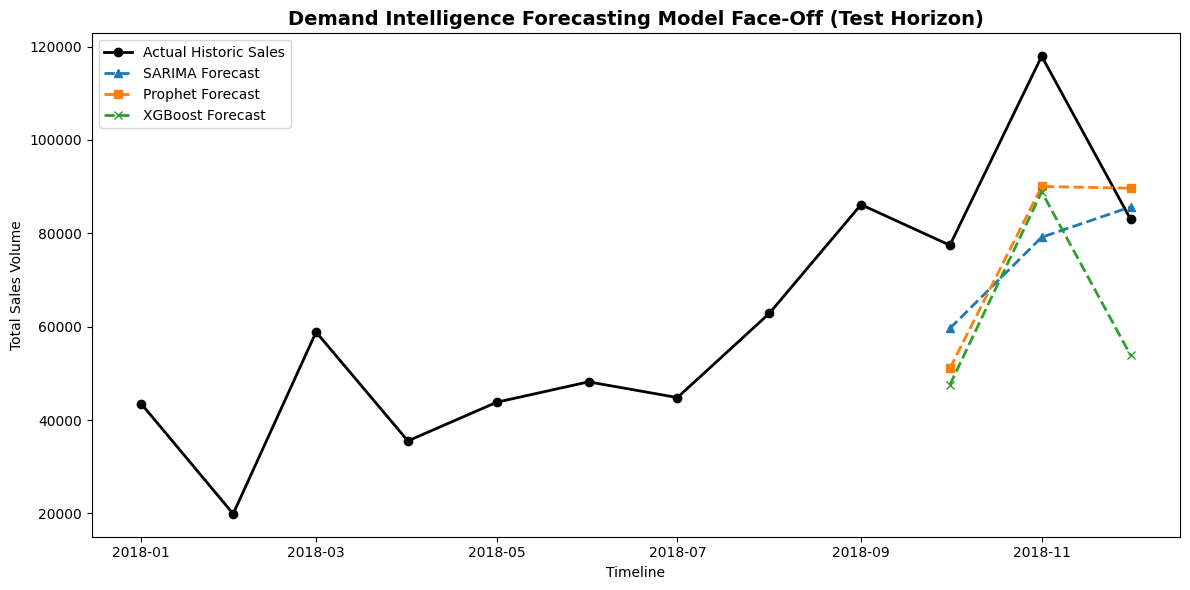

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# --- 1. Prepare Train/Test Split (Last 3 months as validation test set) ---
ts_data = df_merged_monthly.set_index('Order Date')['Sales'].asfreq('MS')
train_ts = ts_data.iloc[:-3]
test_ts = ts_data.iloc[-3:]

# Dictionary to hold metrics and predictions
model_perf = {}

def calculate_mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# ==========================================
# MODEL 1: SARIMA
# Parameters chosen based on decomposition: d=0 (stationary), 
# seasonal period m=12 with strong annual cycles.
# ==========================================
print("Training SARIMA...")
sarima_model = SARIMAX(train_ts, order=(1, 0, 1), seasonal_order=(1, 0, 1, 12))
sarima_fit = sarima_model.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=3)

model_perf['SARIMA'] = {
    'MAE': mean_absolute_error(test_ts, sarima_pred),
    'RMSE': np.sqrt(mean_squared_error(test_ts, sarima_pred)),
    'MAPE': calculate_mape(test_ts, sarima_pred),
    'M1': sarima_pred.iloc[0], 'M2': sarima_pred.iloc[1], 'M3': sarima_pred.iloc[2]
}

# ==========================================
# MODEL 2: FACEBOOK PROPHET
# ==========================================
print("Training Facebook Prophet...")
prophet_df = train_ts.reset_index().rename(columns={'Order Date': 'ds', 'Sales': 'y'})
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_df)

future_df = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future_df)
prophet_pred = prophet_forecast['yhat'].iloc[-3:].values

model_perf['Prophet'] = {
    'MAE': mean_absolute_error(test_ts, prophet_pred),
    'RMSE': np.sqrt(mean_squared_error(test_ts, prophet_pred)),
    'MAPE': calculate_mape(test_ts, prophet_pred),
    'M1': prophet_pred[0], 'M2': prophet_pred[1], 'M3': prophet_pred[2]
}

# ==========================================
# MODEL 3: XGBOOST REGRESSOR
# Converting the time-series into a supervised ML framework
# ==========================================
print("Training XGBoost Regressor...")
ml_df = pd.DataFrame(ts_data)
for i in range(1, 4):
    ml_df[f'Lag_{i}'] = ml_df['Sales'].shift(i)
ml_df['Rolling_Mean'] = ml_df['Sales'].shift(1).rolling(window=3).mean()
ml_df['Month'] = ml_df.index.month
ml_df['Quarter'] = ml_df.index.quarter

ml_df = ml_df.dropna()
features = [col for col in ml_df.columns if col != 'Sales']

# Separate back into train/test splits
X_train, y_train = ml_df[features].iloc[:-3], ml_df['Sales'].iloc[:-3]
X_test, y_test = ml_df[features].iloc[-3:], ml_df['Sales'].iloc[-3:]

xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

model_perf['XGBoost'] = {
    'MAE': mean_absolute_error(y_test, xgb_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
    'MAPE': calculate_mape(y_test, xgb_pred),
    'M1': xgb_pred[0], 'M2': xgb_pred[1], 'M3': xgb_pred[2]
}

# ==========================================
# COMPILE AND DISPLAY COMPARISON MATRICES
# ==========================================
comparison_df = pd.DataFrame(model_perf).T
comparison_df.columns = ['MAE', 'RMSE', 'MAPE', 'Forecast Month 1', 'Forecast Month 2', 'Forecast Month 3']
print("\n=== TASK 3: FORECASTING MODEL PERFORMANCE COMPARISON ===")
display(comparison_df.round(2))

# Plot actuals vs predictions for evaluation visualization
plt.figure(figsize=(12, 6))
plt.plot(ts_data.index[-12:], ts_data.iloc[-12:], label='Actual Historic Sales', color='black', marker='o', lw=2)
plt.plot(test_ts.index, sarima_pred, label='SARIMA Forecast', linestyle='--', marker='^', lw=2)
plt.plot(test_ts.index, prophet_pred, label='Prophet Forecast', linestyle='--', marker='s', lw=2)
plt.plot(test_ts.index, xgb_pred, label='XGBoost Forecast', linestyle='--', marker='x', lw=2)
plt.title('Demand Intelligence Forecasting Model Face-Off (Test Horizon)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Total Sales Volume')
plt.legend()
plt.tight_layout()
plt.savefig('charts/actual_vs_predicted.png', dpi=300)
plt.show()